# AlphaEvolve on Cluster Toolkit and Cloud Batch

The AlphaEvolve on Cluster Toolkit provides a scalable infrastructure for running evolutionary code optimization experiments on Google Cloud. It automates the process of generating, compiling, and evaluating code candidates using LLMs and Cloud Batch.

## Running Your Experiment
---

You can run the experiment via Google Cloud Batch ([see below](#submit_batch)). This is intended for running full jobs after development is completed. All evaluations are executed on scalable Google Cloud Batch VMs.




### Key Environment Variables
---
| Variable | Default / Example | Description |
|---|---|---|
|`_PROJECT_ID` | `your-project-id` | The Google Cloud project ID where resources will be deployed. |
|`_DEPLOYMENT_NAME` | `alpha-evolve-infra` |  Used to uniquely prefix experiment resources (such as GCS folders and Cloud Batch jobs). |
|`_REGION` | `us-central1` |  Google Cloud dynamic compute region. |
|`_EVALUATION_MACHINE_TYPE` | `n2-standard-4` | Custom VM evaluator constraints machine type for batch mode. |
|`_EVALUATION_PROVISIONING_MODEL` | `SPOT` | Provisioning model for Evaluator Cloud Batch VMs (`SPOT` or `STANDARD`). |
|`_MAX_PROGRAMS_EVALUATED`|`10`|This is the number of candidate programs that will be evaluated when the controller job is run.|
|`_MAX_PROGRAMS_GENERATED`|`100`|This is the maximum number of candidate programs the AlphaEvolve API will supply. |

### Install Dependencies
Run the cell below to install required Python packages in this Colab environment.

In [ ]:
# Install required packages
!pip install --no-cache-dir google-cloud-batch python-dotenv termcolor
!apt-get update && apt-get install -y gettext-base

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.0/181.0 kB 6.8 MB/s eta 0:00:00


Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:3 https://packages.cloud.google.com/apt gcsfuse-jammy InRelease
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,083 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Pac

### Mount GCS Bucket

Run the cell below to link this notebook with your Cloud Storage bucket.

In [ ]:
# Create a directory for the mount
!mkdir -p /data

# Get the bucket name from the environment variable
import os
bucket_name = os.getenv('_CLOUD_BUCKET_NAME')

# Mount the bucket
!gcsfuse --implicit-dirs {bucket_name} /data


{"timestamp":{"seconds":1783368909,"nanos":347235468},"severity":"INFO","message":"Start gcsfuse/3.10.0 (Go version go1.26.4) for app \"\" using mount point: /data\n","mount-id":"alpha-evolve-3c5ac3eb"}
{"timestamp":{"seconds":1783368909,"nanos":347267249},"severity":"INFO","message":"GCSFuse Config","mount-id":"alpha-evolve-3c5ac3eb","CLI Flags":{"implicit-dirs":"true"}}
{"timestamp":{"seconds":1783368909,"nanos":347289736},"severity":"INFO","message":"GCSFuse Config","mount-id":"alpha-evolve-3c5ac3eb","Full Config":{"AppName":"","CacheDir":"","CloudProfiler":{"AllocatedHeap":true,"Cpu":true,"Enabled":false,"Goroutines":false,"Heap":true,"Label":"gcsfuse-0.0.0","Mutex":false,"ServiceName":"gcsfuse"},"Debug":{"ExitOnInvariantViolation":false,"Fuse":false,"Gcs":false,"LogMutex":false},"DisableAutoconfig":false,"DummyIo":{"Enable":false,"PerMbLatency":0,"ReaderLatency":0},"EnableAtomicRenameObject":true,"EnableGoogleLibAuth":true,"EnableHns":true,"EnableNewReader":true,"EnableStandardSym

### Load Infrastructure & Discover Experiments
---
Run the cell below to load your baseline infrastructure configuration from GCS (`data/config/variables-infra.env`), dynamically discover all active experiments from Cloud Metadata, and interactively select the experiment you want to run and validate.

In [ ]:
import subprocess
import json
import os
from dotenv import load_dotenv

def load_infra_and_experiment():
    # 1. Load baseline infrastructure configuration first
    infra_env = "/data/config/variables-infra.env"
    if os.path.exists(infra_env):
        load_dotenv(infra_env, override=True)
        print(f"Loaded baseline infrastructure variables from {infra_env}")
    else:
        print(f"Warning: Baseline infrastructure configuration not found at {infra_env}")

    # 2. Discover available experiments in project metadata
    project_id = os.environ.get("_PROJECT_ID")
    if not project_id:
        print("Error: _PROJECT_ID environment variable is not set.")
        return

    try:
        result = subprocess.run(
            ["gcloud", "compute", "project-info", "describe", f"--project={project_id}", "--format=json"],
            capture_output=True, text=True, check=True
        )

        project_info = json.loads(result.stdout)
        metadata_items = project_info.get("commonInstanceMetadata", {}).get("items", [])

        experiments = []
        for item in metadata_items:
            key = item["key"]
            if key.endswith("_USER_EXPERIMENT_NAME"):
                exp_name = key.replace("_USER_EXPERIMENT_NAME", "")
                experiments.append(exp_name)

        if experiments:
            print("\nAvailable experiments in Cloud Metadata:")
            for i, exp in enumerate(experiments):
                print(f"[{i}] {exp}")

            choice = input("\nEnter the number of the experiment you want to run (default=0): ")
            if not choice or not choice.strip():
                choice_idx = 0
            else:
                try:
                    choice_idx = int(choice)
                except ValueError:
                    print("Invalid input, defaulting to 0.")
                    choice_idx = 0

            if 0 <= choice_idx < len(experiments):
                user_experiment_name = experiments[choice_idx]
                print(f"\nYou selected: {user_experiment_name}")
                os.environ["_USER_EXPERIMENT_NAME"] = user_experiment_name
                env_path = f"/data/{user_experiment_name}/variables.env"

                print("\nLoading experiment variables for this session:")
                if os.path.exists(env_path):
                    load_dotenv(env_path, override=True)
                    print(f"Loaded experiment variables from {env_path}")
                else:
                    raise FileNotFoundError(f"Experiment variables file not found at {env_path}")

            else:
                print("Invalid choice index.")

            print("\nActive environment variables:")
            for key in sorted(os.environ.keys()):
                if key.startswith("_"):
                    print(f"  {key}={os.environ[key]}")

        else:
            print("No saved experiments found in project metadata.")

    except subprocess.CalledProcessError as e:
        print(f"Error executing gcloud command: {e.stderr}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

load_infra_and_experiment()

Loaded baseline infrastructure variables from /data/config/variables-infra.env

Available experiments in Cloud Metadata:
[0] experiment-1
[1] experiment-2

Enter the number of the experiment you want to run (default=0): 0

You selected: experiment-1

Loading experiment variables for this session:
Loaded experiment variables from /data/experiment-1/variables.env

Active environment variables:
  _ACCELERATOR_COUNT=1
  _ACCELERATOR_TYPE=nvidia-tesla-t4
  _ASSISTANT=default_assistant
  _BASE_URL=discoveryengine.googleapis.com
  _BOOT_DISK_IMAGE=projects/debian-cloud/global/images/family/debian-12
  _CLOUD_BUCKET_NAME=sample_bucket
  _COLLECTION=default_collection
  _CONCURRENCY=4
  _CONTROLLER_IMAGE_URI=us-central1-docker.pkg.dev/sample-project04/alpha-evolve-experiment-experiment-1-repo/experiment-1-controller:latest
  _DELETE_SUCCEEDED_JOBS=true
  _DEPLOYMENT_NAME=alpha-evolve-experiment-experiment-1
  _ENGINE=alpha-evolve-infra-experiment-engine
  _EVALUATION_MACHINE_TYPE=n2-standard-4


## Validate Environment
---
Before running the full experiment at scale, it is recommended to validate that the environment (APIs, permissions, buckets) is correctly set up. This job will run a script that checks access to GCS, Pub/Sub, and AlphaEvolve APIs.

In [ ]:
import os
import re
import yaml
import json
import time
import subprocess
from google.cloud import batch_v1
from IPython.display import display, Markdown

temp_yaml = "/data/config/validation-run-temp.yaml"

try:
    # 1. Read validation-batch.yaml and resolve all environment variable templates using pure Python
    with open("/data/config/validation-batch.yaml", "r") as f:
        yaml_content = f.read()

    resolved_content = os.path.expandvars(yaml_content)
    with open(temp_yaml, "w") as f:
        f.write(resolved_content)

    # 2. Read the resolved YAML to extract variables needed for gcloud and polling
    with open(temp_yaml, "r") as f:
        config_dict = yaml.safe_load(f)

    project_id = os.environ.get("_PROJECT_ID")
    region = os.environ.get("_REGION")
    experiment_name = os.environ.get("_USER_EXPERIMENT_NAME")
    deployment_name = os.environ.get("_DEPLOYMENT_NAME")

    # Shorten suffix and truncate deployment_name so total job ID stays under 63 characters
    suffix = f"-val-{int(time.time())}"
    max_prefix_len = 63 - len(suffix)
    trimmed_prefix = deployment_name[:max_prefix_len].rstrip('-')
    job_id = f"{trimmed_prefix}{suffix}"
    print(f"Submitting validation job: {job_id}")

    # 3. Submit the job using gcloud CLI via subprocess
    cmd_submit = [
        "gcloud",
        "batch",
        "jobs",
        "submit",
        job_id,
        "--config",
        temp_yaml,
        "--location",
        region,
        "--project",
        project_id,
        "--format",
        "json",
    ]

    result = subprocess.run(cmd_submit, capture_output=True, text=True, check=True)
    job_data = json.loads(result.stdout)
    job_name = job_data["name"]
    actual_job_id = job_name.split("/")[-1]
    print(f"Job submitted successfully. Full name: {job_name}")

    # Construct and display the log URL at the top
    log_url = f"https://console.cloud.google.com/batch/jobsDetail/regions/{region}/jobs/{actual_job_id}/logs?project={project_id}"
    display(Markdown(f"[View Job Logs]({log_url})"))

    client = batch_v1.BatchServiceClient()
    print("Polling job status...")
    while True:
        job = client.get_job(name=job_name)
        state = job.status.state.name
        print(f"Current state: {state}")

        if state in ["SUCCEEDED", "FAILED"]:
            print(f"Final state: {state}")
            print("Waiting for logs to flush...")
            time.sleep(5)  # Initial wait

            # Fetch logs using gcloud with retries
            cmd_logs = [
                "gcloud",
                "logging",
                "read",
                f'"{actual_job_id}"',
                "--format=value(jsonPayload.message)",
                f"--project={project_id}",
            ]

            max_retries = 5
            retry_delay = 5
            summary_found = False
            logs_output = ""

            for attempt in range(max_retries):
                print(f"Fetching validation summary from logs (Attempt {attempt + 1}/{max_retries})...")
                try:
                    logs_result = subprocess.run(cmd_logs, capture_output=True, text=True, check=True)
                    logs_output = logs_result.stdout

                    if "=== Validation Summary ===" in logs_output:
                        print("\n=== Retrieved Validation Summary ===")
                        match = re.search(
                            r"=== Validation Summary ===.*?=== End Validation Summary ===",
                            logs_output,
                            re.DOTALL,
                        )
                        if match:
                            print(match.group(0))
                            summary_found = True
                            break
                        else:
                            print("Markers found but could not extract full summary. Retrying...")

                    print("Summary not found yet. Waiting to retry...")
                    time.sleep(retry_delay)
                except subprocess.CalledProcessError as e:
                    print(f"Error fetching logs on attempt {attempt + 1}: {e.stderr}")
                    time.sleep(retry_delay)

            if not summary_found:
                print("Could not find validation summary in logs after retries. You may need to check the full logs link.")

            break
        time.sleep(20)

except subprocess.CalledProcessError as e:
    print(f"Error running command: {e.stderr}")
except Exception as e:
    print(f"Error: {e}")
finally:
    # Clean up temporary file
    print("Cleaning up temporary files...")
    if os.path.exists(temp_yaml):
        os.remove(temp_yaml)

Submitting validation job: alpha-evolve-experiment-experiment-1-val-1783368931
Job submitted successfully. Full name: projects/sample-project04/locations/us-central1/jobs/alpha-evolve-experiment-experiment-1-val-1783368931


[View Job Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-val-1783368931/logs?project=sample-project04)

Polling job status...
Current state: QUEUED
Current state: SCHEDULED
Current state: SCHEDULED
Current state: SCHEDULED
Current state: SCHEDULED
Current state: SCHEDULED
Current state: RUNNING
Current state: RUNNING
Current state: SUCCEEDED
Final state: SUCCEEDED
Waiting for logs to flush...
Fetching validation summary from logs (Attempt 1/5)...

=== Retrieved Validation Summary ===
=== Validation Summary ===
Component            | Status     | Suggested Remediation                             
-------------------------------------------------------------------------------------
Controller Image     | PASSED     | -                                                 
Evaluator Image      | PASSED     | -                                                 
GCS                  | PASSED     | -                                                 
Pub/Sub              | PASSED     | -                                                 
AlphaEvolve API      | PASSED     | -                              

## Submit Controller Job via Cloud Batch
---
<a id="submit_batch"></a>

This enables full batch-mode execution for both the controller and the evaluator engines.

* Starting this batch job creates a dedicated Cloud Batch VM to host the controller, with each subsequent candidate program evaluation operating on its own separate, isolated Batch VM.

* As long as the experiment has not reached a COMPLETED state on the AlphaEvolve platform, experiments can be resumed after the controller job completes.

### Launch the controller job on Cloud Batch
---
The command below runs the controller container on Google Cloud Batch. All evaluation work will be run in individual Cloud Batch jobs.

This commands prepares and submits a Google Cloud Batch job. First, it reads a template configuration file (controller-batch.yaml), replaces any environment variable placeholders (like ${_REGION}) with their current values in your shell, and saves the result as a new file (controller-run.yaml). Then, it uses the gcloud CLI to submit a job to Cloud Batch using that generated configuration file; the job is automatically given a unique name by appending the current timestamp.

In [ ]:
%%bash
# Truncate deployment name prefix and use a shorter controller suffix so total job ID stays under 63 chars
SUFFIX="-ctrl-$(date +%s)"
TRIMMED_PREFIX=$(echo -n "${_DEPLOYMENT_NAME}" | cut -c 1-47 | sed 's/-*$//')
JOB_NAME="${TRIMMED_PREFIX}${SUFFIX}"

envsubst < /data/config/controller-batch.yaml > /data/config/controller-run.yaml
gcloud batch jobs submit "${JOB_NAME}" \
    --location="${_REGION}" \
    --config=/data/config/controller-run.yaml

allocationPolicy:
  instances:
  - policy:
      machineType: n2-standard-4
      provisioningModel: STANDARD
  labels:
    batch-job-id: alpha-evolve-experiment-experiment-1-ctrl-1783369112
  location:
    allowedLocations:
    - regions/us-central1
    - zones/us-central1-a
    - zones/us-central1-b
    - zones/us-central1-c
    - zones/us-central1-f
  serviceAccount:
    email: alpha-evolve-infra-sa@sample-project04.iam.gserviceaccount.com
createTime: '2026-07-06T20:18:33.318495244Z'
logsPolicy:
  destination: CLOUD_LOGGING
name: projects/sample-project04/locations/us-central1/jobs/alpha-evolve-experiment-experiment-1-ctrl-1783369112
status:
  runDuration: 0s
  state: QUEUED
taskGroups:
- name: projects/660456334398/locations/us-central1/jobs/alpha-evolve-experiment-experiment-1-ctrl-1783369112/taskGroups/group0
  parallelism: '1'
  taskCount: '1'
  taskSpec:
    computeResource:
      cpuMilli: '2000'
      memoryMib: '2000'
    runnables:
    - container:
        imageUri: us-cent

Job alpha-evolve-exper-862e1589-5af2-4f310 was successfully submitted.


### List Batch jobs: what is running?
---

This code cell will list all the batch jobs that are currently running on Google cloud batch. You can also see the same results at:
[Google Cloud Console](https://console.cloud.google.com/batch/jobs).

The [Google Cloud Console](https://console.cloud.google.com/batch/jobs) is useful, because you can see logging and deeper information about the running Batch jobs. Futhermore, you can delete old jobs that are listed but not part of the current experiment.

Normally, you would see a job with `controller` in the name, along with several jobs with `workers` in the name.

In [ ]:
import os
import json
from google.cloud import batch_v1
from IPython.display import display, Markdown

def list_batch_jobs_pretty():
    project_id = os.environ.get("_PROJECT_ID")
    region = os.environ.get("_REGION", "us-central1")

    if not project_id:
        display(Markdown(f"**Error**: Environment variable `_PROJECT_ID` is not set."))
        return

    client = batch_v1.BatchServiceClient()
    parent = f"projects/{project_id}/locations/{region}"
    request = batch_v1.ListJobsRequest(parent=parent)

    try:
        page_result = client.list_jobs(request=request)

        jobs = list(page_result)
        jobs.sort(key=lambda x: x.create_time, reverse=True)

        table_lines = []
        table_lines.append(f"| Job ID | Status | Created | Logs Link |")
        table_lines.append(f"|---|---|---|---|")

        for job in jobs:
            job_id = job.name.split('/')[-1]
            state = job.status.state.name
            create_time = job.create_time.strftime("%Y-%m-%d %H:%M")

            if state == "SUCCEEDED":
                status_str = f'<font color="green"><span style="color:green">{state}</span></font>'
            elif state in ["RUNNING", "SCHEDULED", "QUEUED"]:
                status_str = f'<font color="orange"><span style="color:orange">{state}</span></font>'
            elif state == "FAILED":
                status_str = f'<font color="red"><span style="color:red">{state}</span></font>'
            else:
                status_str = state

            log_url = f"https://console.cloud.google.com/batch/jobsDetail/regions/{region}/jobs/{job_id}/logs?project={project_id}"
            log_link = f"[Logs]({log_url})"

            table_lines.append(f"| {job_id} | {status_str} | {create_time} | {log_link} |")

        display(Markdown('\n'.join(table_lines)))

    except Exception as e:
        display(Markdown(f"**Error** listing jobs: {e}"))

if __name__ == "__main__":
    list_batch_jobs_pretty()

| Job ID | Status | Created | Logs Link |
|---|---|---|---|
| alpha-evolve-experiment-experiment-1-worker-9784189982451095033 | <font color="orange"><span style="color:orange">SCHEDULED</span></font> | 2026-07-06 20:23 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-worker-9784189982451095033/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-1-worker-9784189982451095295 | DELETION_IN_PROGRESS | 2026-07-06 20:21 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-worker-9784189982451095295/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-1-worker-9784189982451094771 | DELETION_IN_PROGRESS | 2026-07-06 20:21 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-worker-9784189982451094771/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-1-worker-9784189982451094509 | <font color="red"><span style="color:red">FAILED</span></font> | 2026-07-06 20:21 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-worker-9784189982451094509/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-1-ctrl-1783369112 | <font color="orange"><span style="color:orange">RUNNING</span></font> | 2026-07-06 20:18 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-ctrl-1783369112/logs?project=sample-project04) |

## Analysis
---
The following sections give some visibility into the data produced by the Alpha Evolve experiment.

> **Note:** several evaluation jobs need to complete before this analysis will have usefule data.

### View the CSV file output: `data` directory
---
For convenience we capture all the output of the evaluations in a CSV file.  "data/experiment-1/results.csv".

Click on the "data" directory on the left navigation. Then click on "experiment-1/results.csv".

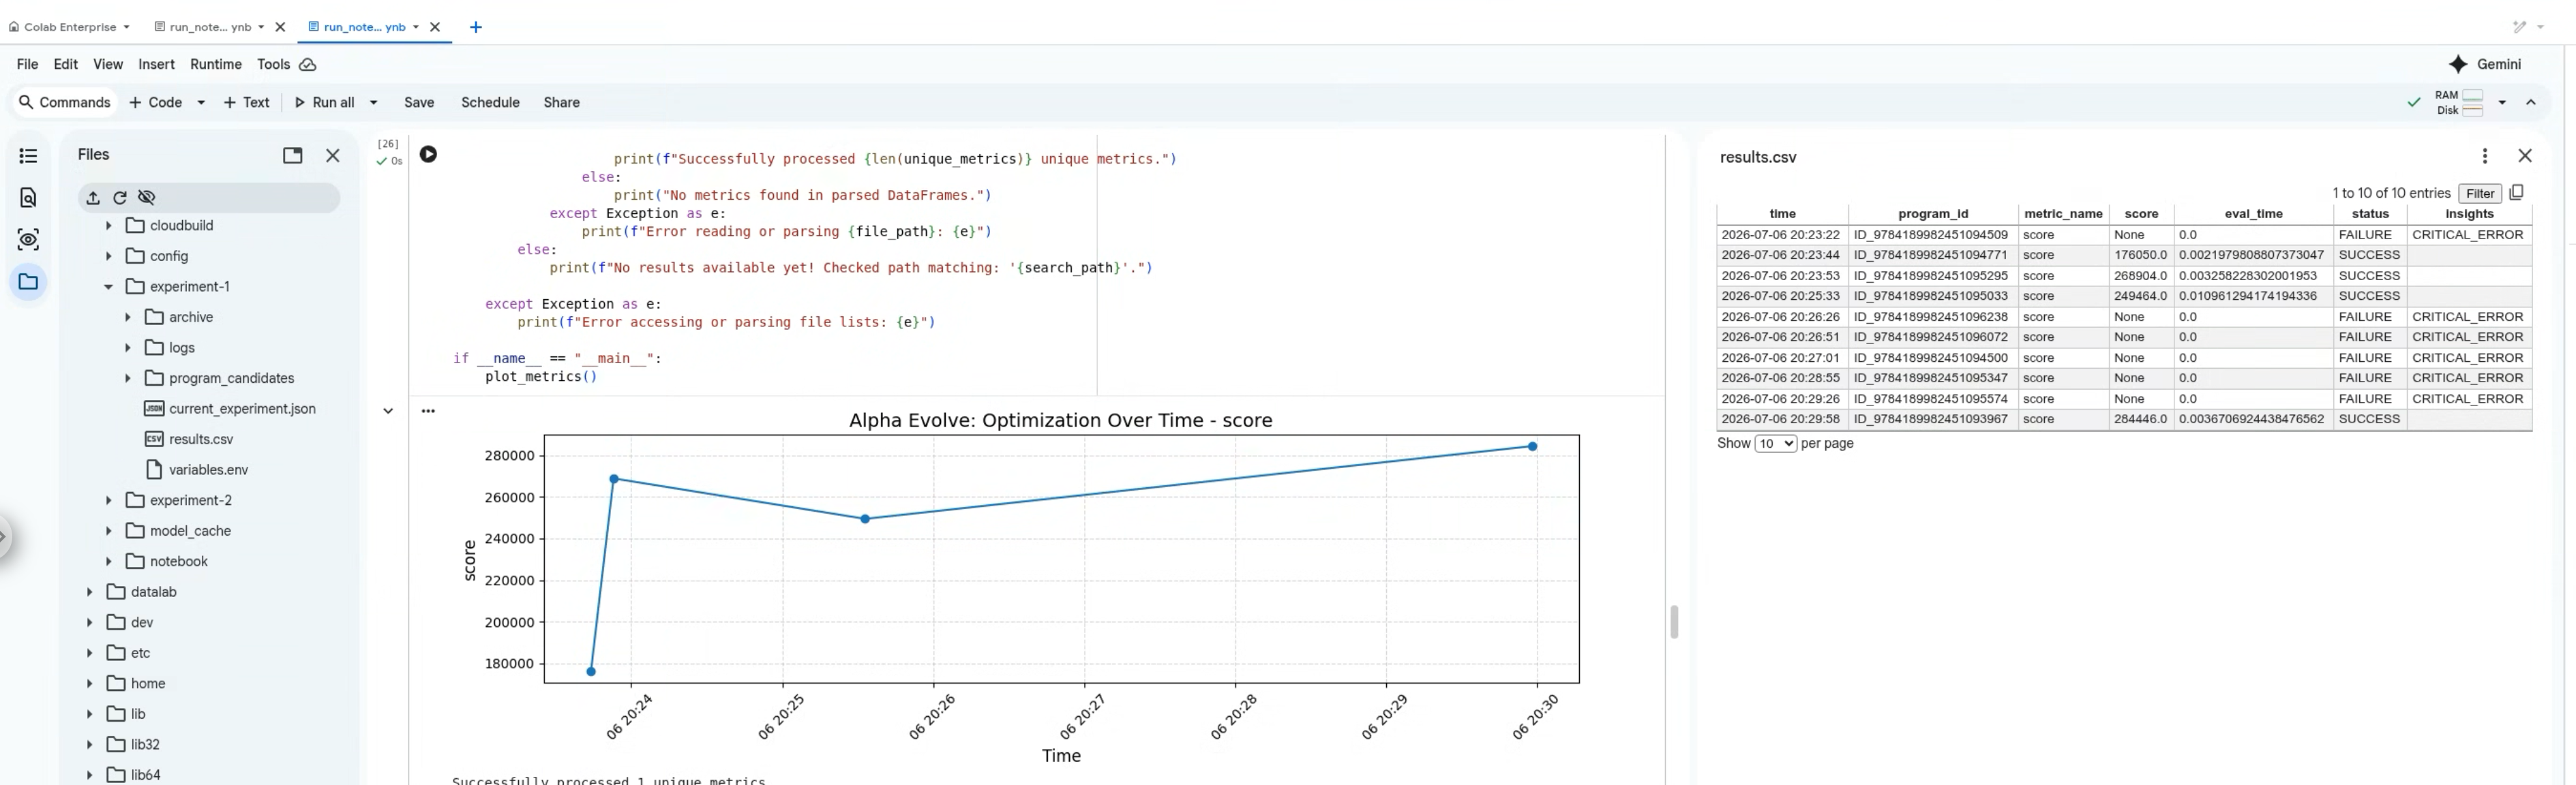

### Plot the `score` metric as a function of time.
---
This plots the `score` value from each of the evaluated program candidates as a function of time. Here we plot the data in the "experiment-1/results.csv".

There are only points for successful evaluations. If the Python code in the program candidate crashed, there will be no results for that program.



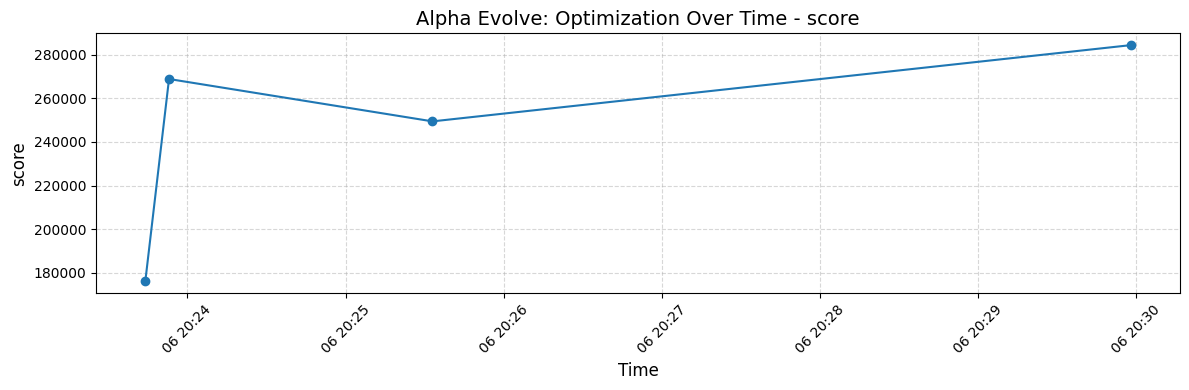

Successfully processed 1 unique metrics.


In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_metrics():
    try:
        # 1. Use glob to find files under data/results/
        user_experiment_name = os.environ.get("_USER_EXPERIMENT_NAME")
        search_path = f'/data/{user_experiment_name}/results.csv'
        file_list = glob.glob(search_path)

        if file_list:
            # Since we only read one results.csv file, we take the first match and avoid loops!
            file_path = file_list[0]
            try:
                df = pd.read_csv(file_path)

                # 2. Sorting and Plotting
                df['time'] = pd.to_datetime(df['time'])
                df = df.sort_values(by='time')

                # Loop and generate separate plots for each unique metric
                unique_metrics = df['metric_name'].dropna().unique()

                if len(unique_metrics) > 0:
                    for metric in unique_metrics:
                        plt.figure(figsize=(12, 4))

                        df_filtered = df[df['metric_name'] == metric]

                        # Ensure no NaN values in score or time for continuous plotting
                        df_filtered = df_filtered.dropna(subset=['score', 'time'])
                        # Keep rows where 'score' is NOT -1e12
                        df_filtered = df_filtered[(df_filtered['score'] != -1e12)]
                        # Explicitly sort again after filtering to ensure chronological order for matplotlib
                        df_filtered = df_filtered.sort_values('time')

                        plt.plot(df_filtered['time'], df_filtered['score'], marker='o', linestyle='-', color='#1f77b4', linewidth=1.5)

                        # Labels and formatting
                        plt.title(f'Alpha Evolve: Optimization Over Time - {metric}', fontsize=14)
                        plt.xlabel('Time', fontsize=12)
                        plt.ylabel(metric, fontsize=12)
                        plt.xticks(rotation=45)
                        plt.grid(True, linestyle='--', alpha=0.5)

                        plt.tight_layout()
                        plt.show()

                    print(f"Successfully processed {len(unique_metrics)} unique metrics.")
                else:
                    print("No metrics found in parsed DataFrames.")
            except Exception as e:
                print(f"Error reading or parsing {file_path}: {e}")
        else:
            print(f"No results available yet! Checked path matching: '{search_path}'.")

    except Exception as e:
        print(f"Error accessing or parsing file lists: {e}")

if __name__ == "__main__":
    plot_metrics()

### Plot the number of successful candidate programs vs failed programs.
---
Inevitably, some of the candidate programs are not syntactically or functionally correct. In that case, we track a failed result. This information is provided to the AlphaEvolve API and we share it here for information purposes.

Dynamically resolved and using metric: score


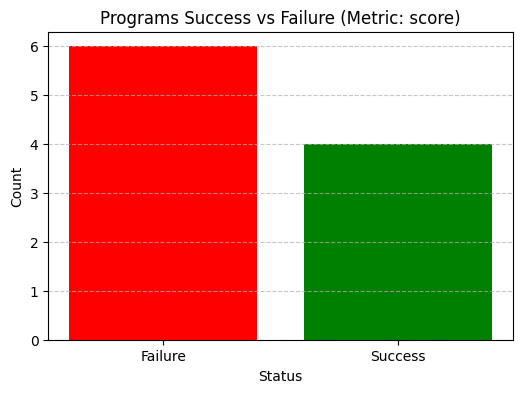

Total Success for score: 4
Total Failure for score: 6


In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_success_ves_failure():
    try:
        # 1. Use glob to find file (same as cell 16)
        user_experiment_name = os.environ.get("_USER_EXPERIMENT_NAME")
        search_path = f'/data/{user_experiment_name}/results.csv'
        file_list = glob.glob(search_path)

        if file_list:
            file_path = file_list[0]
            try:
                df = pd.read_csv(file_path)

                # 2. Extract unique metrics dynamically (same as cell 16)
                unique_metrics = df['metric_name'].dropna().unique()

                if len(unique_metrics) > 0:
                    # Resolve single metric dynamically as requested
                    target_metric = unique_metrics[0]
                    print(f"Dynamically resolved and using metric: {target_metric}")

                    plt.figure(figsize=(6, 4))

                    metric_df = df[df['metric_name'] == target_metric].copy()

                    # Clean score values
                    metric_df['score'] = pd.to_numeric(metric_df['score'], errors='coerce')

                    # NOTE: If minimizing a metric (passed as negative score), switch this to:
                    # metric_df['success'] = metric_df['score'] > -threshold
                    # Defaulting to score > 0.
                    metric_df['success'] = metric_df['score'] > 0
                    counts = metric_df['success'].value_counts()

                    # Plot
                    labels = []
                    colors = []
                    for val in counts.index:
                        if val:
                            labels.append('Success')
                            colors.append('green')
                        else:
                            labels.append('Failure')
                            colors.append('red')

                    plt.bar([str(val) for val in counts.index], counts.values, color=colors)
                    plt.title(f'Programs Success vs Failure (Metric: {target_metric})')
                    plt.xlabel('Status')
                    plt.ylabel('Count')
                    plt.xticks([str(val) for val in counts.index], labels)
                    plt.grid(axis='y', linestyle='--', alpha=0.7)
                    plt.show()

                    print(f"Total Success for {target_metric}: {counts.get(True, 0)}")
                    print(f"Total Failure for {target_metric}: {counts.get(False, 0)}")

                else:
                    print("No metrics found in parsed DataFrames.")
            except Exception as e:
                print(f"Error reading or parsing {file_path}: {e}")
        else:
            print(f"No results available yet! Checked path matching: '{search_path}'.")

    except Exception as e:
        print(f"Error accessing or parsing file lists: {e}")

if __name__ == "__main__":
    plot_success_ves_failure()

### Compare two candidate program instances.
---
For the purposes of illustration, we provide a `diff` of two candidate programs. Typically, there is a substantial difference between candidates.


In [ ]:
%%bash
# Note: Make sure to adjust file names and directory structure
files=($(ls -1 /data/$_USER_EXPERIMENT_NAME/archive/$_PROGRAMS_DIR/$_DEPLOYMENT_NAME-*/src/sort.hpp | head -n 2))
sdiff "${files[0]}" "${files[1]}"
exit 0

// Copyright 2026 Google LLC					// Copyright 2026 Google LLC
//								//
// Licensed under the Apache License, Version 2.0 (the "Licen	// Licensed under the Apache License, Version 2.0 (the "Licen
// you may not use this file except in compliance with the Li	// you may not use this file except in compliance with the Li
// You may obtain a copy of the License at			// You may obtain a copy of the License at
//								//
//     http://www.apache.org/licenses/LICENSE-2.0		//     http://www.apache.org/licenses/LICENSE-2.0
//								//
// Unless required by applicable law or agreed to in writing,	// Unless required by applicable law or agreed to in writing,
// distributed under the License is distributed on an "AS IS"	// distributed under the License is distributed on an "AS IS"
// WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either expre	// WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either expre
// See the License for the specific language governing permis	// See the License for the s

---

# Show how change experiment run

### Deploy your specific example on your machine

This command builds the containers for the signal_processing example and sets the experiment name to experiment-2. It also automatically uploads these containers to the Artifact Registry so they can be accessed by the VMs when the Cloud Batch job is submitted.

On the machine that has the alpha-evolve tarball, run the gcluster deploy command:
```bash
export USER_EXPERIMENT_NAME=experiment-2               # do not use underscores, only hyphens
export EXAMPLE_DIR=user_examples/signal_processing    # or any other example directory

gcluster deploy alpha-evolve-experiment.yaml -l IGNORE -d alpha-evolve-deployment.yaml -o ../deployment \
  --vars project_id=${PROJECT_ID} \
  --vars region=${REGION} \
  --vars existing_bucket_name=${BUCKET_NAME} \
  --vars example_dir=${EXAMPLE_DIR} \
  --vars user_experiment_name=${USER_EXPERIMENT_NAME} \
  -w --auto-approve
```

### Expected output for the above deploynment command
If deployment is successful, you should expect the following output at the end of the deployment command run:

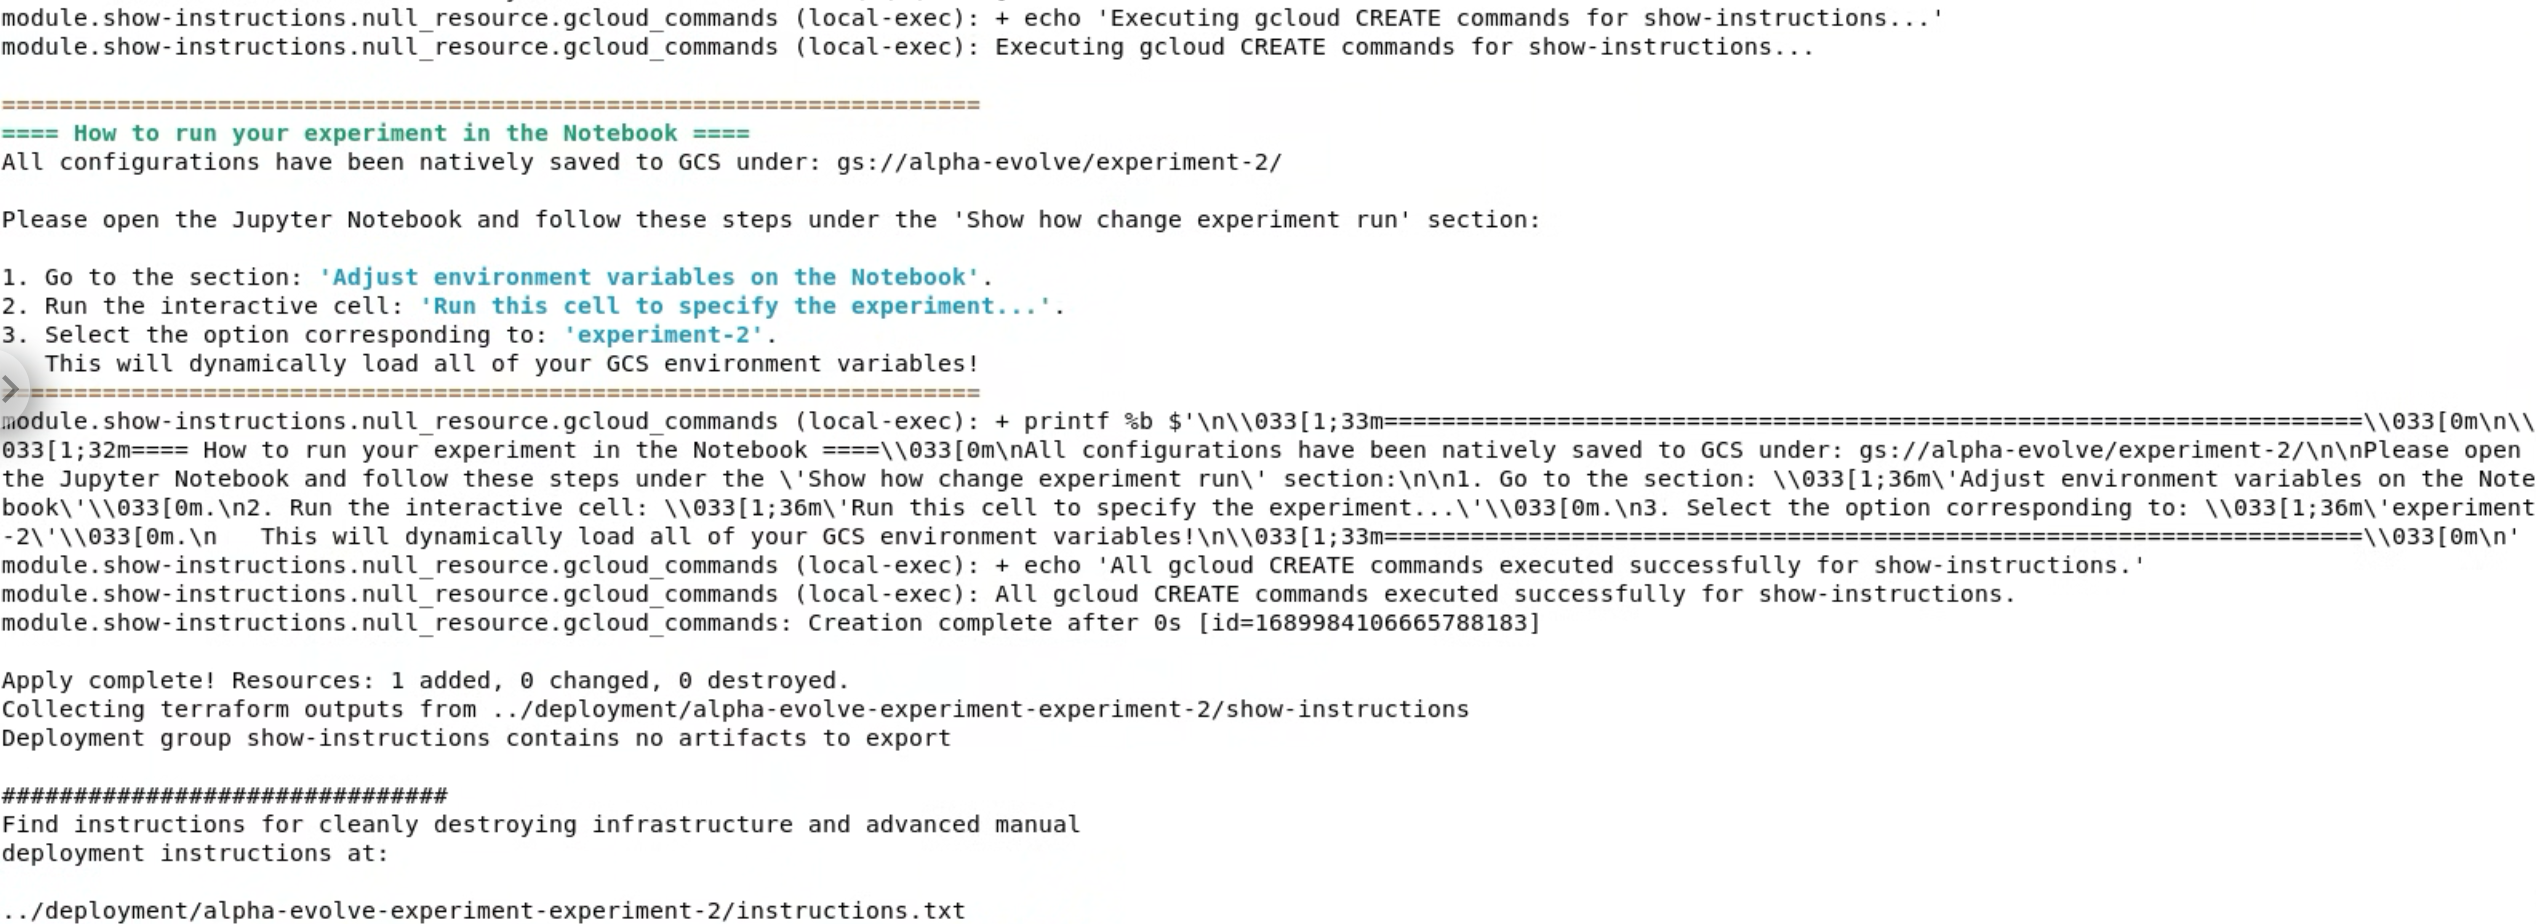


### Adjust environment variables on the Notebook
---
<a id="adjust_variables"></a>

As noted above, all the inputs to the controller jobs are controlled via ENVIRONMENT variables. You will modify how the jobs runs by changing the environment variables.
The code sample below demonstrates how to dynamically execute a different or custom experiment within this same notebook, allowing you to easily test and optimize your own custom-created examples.
The typical flow will be as follows:

1. You submit the batch job to evaluate 10 candidate programs.
2. You observe the performance for this limited set.
3. If the evaluations seem correct, you can change the `_MAX_PROGRAMS_EVALUATED` to a larger value.
4. The maximumn number of candidate programs that can be run is `_MAX_PROGRAMS_GENERATED`. The AlphaEvolve API will not return more candidate programs after this number is reached.

> [!NOTE]
> **Dynamic Environment Loading:**
> The notebook uses the **Google Cloud GCE Metadata Server** to dynamically discover all active experiments deployed on this cluster.
> When you select an experiment in the cell below, it automatically reads the corresponding `variables.env` file directly from your **GCS Bucket** and loads all environment variables (such as `_REPO_NAME`, `_MOUNT_PATH`, `_EVALUATION_MODE`, etc.) natively into your session. No manual configuration of variables is required!

### Select and Load Deployed Experiment Variables
---
Run the interactive cell below to discover and list all active experiments deployed on this cluster, choose the one you want to execute, and dynamically load its exact configurations from GCS into your session.

In [ ]:
import subprocess
import json
import os
from dotenv import load_dotenv

project_id = os.environ.get("_PROJECT_ID")

def load_experiment_env():
    if not project_id:
        print("Error: _PROJECT_ID environment variable is not set. Please run the infrastructure loading cell earlier in the notebook.")
        return

    try:
        # 1. Load baseline infrastructure variables first
        infra_env = "/data/config/variables-infra.env"
        if os.path.exists(infra_env):
            load_dotenv(infra_env, override=True)
            print(f"Loaded baseline infrastructure variables from {infra_env}")

        # 2. Discover available experiments in project metadata
        result = subprocess.run(
            ["gcloud", "compute", "project-info", "describe", f"--project={project_id}", "--format=json"],
            capture_output=True, text=True, check=True
        )

        project_info = json.loads(result.stdout)
        metadata_items = project_info.get("commonInstanceMetadata", {}).get("items", [])

        experiments = []
        for item in metadata_items:
            key = item["key"]
            if key.endswith("_USER_EXPERIMENT_NAME"):
                exp_name = key.replace("_USER_EXPERIMENT_NAME", "")
                experiments.append(exp_name)

        if experiments:
            print("\nAvailable experiments in Cloud Metadata:")
            for i, exp in enumerate(experiments):
                print(f"[{i}] {exp}")

            choice = input("\nEnter the number of the experiment you want to run: ")
            try:
                choice_idx = int(choice)
                user_experiment_name = experiments[choice_idx]
                print(f"\nYou selected: {user_experiment_name}")

                os.environ["_USER_EXPERIMENT_NAME"] = user_experiment_name
                env_path = f"/data/{user_experiment_name}/variables.env"

                print("\nLoading experiment variables for this session:")
                if os.path.exists(env_path):
                    load_dotenv(env_path, override=True)
                    print(f"Loaded experiment variables from {env_path}")
                else:
                    print(f"Error: Experiment variables file not found at {env_path}")

                print("\nActive environment variables:")
                for key in sorted(os.environ.keys()):
                    if key.startswith("_"):
                        print(f"  {key}={os.environ[key]}")

            except (ValueError, IndexError):
                print("Invalid choice. Please enter a valid number.")
        else:
            print("No saved experiments found in project metadata.")

    except subprocess.CalledProcessError as e:
        print(f"Error executing gcloud command: {e.stderr}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

load_experiment_env()

Loaded baseline infrastructure variables from /data/config/variables-infra.env

Available experiments in Cloud Metadata:
[0] experiment-1
[1] experiment-2

Enter the number of the experiment you want to run: 1

You selected: experiment-2

Loading experiment variables for this session:
Loaded experiment variables from /data/experiment-2/variables.env

Active environment variables:
  _ACCELERATOR_COUNT=1
  _ACCELERATOR_TYPE=nvidia-tesla-t4
  _ASSISTANT=default_assistant
  _BASE_URL=discoveryengine.googleapis.com
  _BOOT_DISK_IMAGE=projects/debian-cloud/global/images/family/debian-12
  _CLOUD_BUCKET_NAME=sample_bucket
  _COLLECTION=default_collection
  _CONCURRENCY=4
  _CONTROLLER_IMAGE_URI=us-central1-docker.pkg.dev/sample-project04/alpha-evolve-experiment-experiment-2-repo/experiment-2-controller:latest
  _DELETE_SUCCEEDED_JOBS=true
  _DEPLOYMENT_NAME=alpha-evolve-experiment-experiment-2
  _ENGINE=alpha-evolve-infra-experiment-engine
  _EVALUATION_MACHINE_TYPE=n2-standard-4
  _EVALUATIO

### Launch the controller job on Cloud Batch
---
The command below runs the controller container on Google Cloud Batch. All evaluation work will be run in individual Cloud Batch jobs.

This commands prepares and submits a Google Cloud Batch job. First, it reads a template configuration file (controller-batch.yaml), replaces any environment variable placeholders (like ${_REGION}) with their current values in your shell, and saves the result as a new file (controller-run.yaml). Then, it uses the gcloud CLI to submit a job to Cloud Batch using that generated configuration file; the job is automatically given a unique name by appending the current timestamp.

In [ ]:
%%bash
# Truncate deployment name prefix and use a shorter controller suffix so total job ID stays under 63 chars
SUFFIX="-ctrl-$(date +%s)"
TRIMMED_PREFIX=$(echo -n "${_DEPLOYMENT_NAME}" | cut -c 1-47 | sed 's/-*$//')
JOB_NAME="${TRIMMED_PREFIX}${SUFFIX}"

envsubst < /data/config/controller-batch.yaml > /data/config/controller-run.yaml
gcloud batch jobs submit "${JOB_NAME}" \
    --location="${_REGION}" \
    --config=/data/config/controller-run.yaml

allocationPolicy:
  instances:
  - policy:
      machineType: n2-standard-4
      provisioningModel: STANDARD
  labels:
    batch-job-id: alpha-evolve-experiment-experiment-2-ctrl-1783369915
  location:
    allowedLocations:
    - regions/us-central1
    - zones/us-central1-a
    - zones/us-central1-b
    - zones/us-central1-c
    - zones/us-central1-f
  serviceAccount:
    email: alpha-evolve-infra-sa@sample-project04.iam.gserviceaccount.com
createTime: '2026-07-06T20:31:56.277872489Z'
logsPolicy:
  destination: CLOUD_LOGGING
name: projects/sample-project04/locations/us-central1/jobs/alpha-evolve-experiment-experiment-2-ctrl-1783369915
status:
  runDuration: 0s
  state: QUEUED
taskGroups:
- name: projects/660456334398/locations/us-central1/jobs/alpha-evolve-experiment-experiment-2-ctrl-1783369915/taskGroups/group0
  parallelism: '1'
  taskCount: '1'
  taskSpec:
    computeResource:
      cpuMilli: '2000'
      memoryMib: '2000'
    runnables:
    - container:
        imageUri: us-cent

Job alpha-evolve-exper-b1633341-ec97-4d650 was successfully submitted.


### List Batch jobs: what is running?
---

This code cell will list all the batch jobs that are currently running on Google cloud batch. You can also see the same results at:
[Google Cloud Console](https://console.cloud.google.com/batch/jobs).

The [Google Cloud Console](https://console.cloud.google.com/batch/jobs) is useful, because you can see logging and deeper information about the running Batch jobs. Futhermore, you can delete old jobs that are listed but not part of the current experiment.

Normally, you would see a job with `controller` in the name, along with several jobs with `workers` in the name.

In [ ]:
import os
import json
from google.cloud import batch_v1
from termcolor import colored

list_batch_jobs_pretty()

| Job ID | Status | Created | Logs Link |
|---|---|---|---|
| alpha-evolve-experiment-experiment-2-worker-7120567757703439837 | <font color="orange"><span style="color:orange">SCHEDULED</span></font> | 2026-07-06 20:34 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-2-worker-7120567757703439837/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-2-worker-7120567757703440171 | <font color="orange"><span style="color:orange">SCHEDULED</span></font> | 2026-07-06 20:34 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-2-worker-7120567757703440171/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-2-worker-7120567757703439169 | <font color="orange"><span style="color:orange">SCHEDULED</span></font> | 2026-07-06 20:34 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-2-worker-7120567757703439169/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-2-ctrl-1783369915 | <font color="orange"><span style="color:orange">RUNNING</span></font> | 2026-07-06 20:31 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-2-ctrl-1783369915/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-1-worker-9784189982451095801 | <font color="red"><span style="color:red">FAILED</span></font> | 2026-07-06 20:27 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-worker-9784189982451095801/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-1-worker-9784189982451095574 | <font color="red"><span style="color:red">FAILED</span></font> | 2026-07-06 20:27 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-worker-9784189982451095574/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-1-worker-9784189982451095347 | <font color="red"><span style="color:red">FAILED</span></font> | 2026-07-06 20:26 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-worker-9784189982451095347/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-1-worker-9784189982451094500 | <font color="red"><span style="color:red">FAILED</span></font> | 2026-07-06 20:24 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-worker-9784189982451094500/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-1-worker-9784189982451096072 | <font color="red"><span style="color:red">FAILED</span></font> | 2026-07-06 20:24 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-worker-9784189982451096072/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-1-worker-9784189982451096238 | <font color="red"><span style="color:red">FAILED</span></font> | 2026-07-06 20:24 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-worker-9784189982451096238/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-1-worker-9784189982451094509 | <font color="red"><span style="color:red">FAILED</span></font> | 2026-07-06 20:21 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-worker-9784189982451094509/logs?project=sample-project04) |
| alpha-evolve-experiment-experiment-1-ctrl-1783369112 | <font color="green"><span style="color:green">SUCCEEDED</span></font> | 2026-07-06 20:18 | [Logs](https://console.cloud.google.com/batch/jobsDetail/regions/us-central1/jobs/alpha-evolve-experiment-experiment-1-ctrl-1783369112/logs?project=sample-project04) |

## Analysis
---
The following sections give some visibility into the data produced by the Alpha Evolve experiment.

> **Note:** several evaluation jobs need to complete before this analysis will have usefule data.

### View the CSV file output: `data` directory
---
For convenience we capture all the output of the evaluations in a CSV file.  "data/[USER_EXPERIMENT_NAME]/results.csv".

Click on the "data" directory on the left navigation. Then click on "[USER_EXPERIMENT_NAME]/results.csv".

---

### Plot the `score` metric as a function of time.
---
This plots the `score` value from each of the evaluated program candidates as a function of time. Here we plot the data in the "[USER_EXPERIMENT_NAME]/results.csv".

There are only points for successful evaluations. If the Python code in the program candidate crashed, there will be no results for that program.



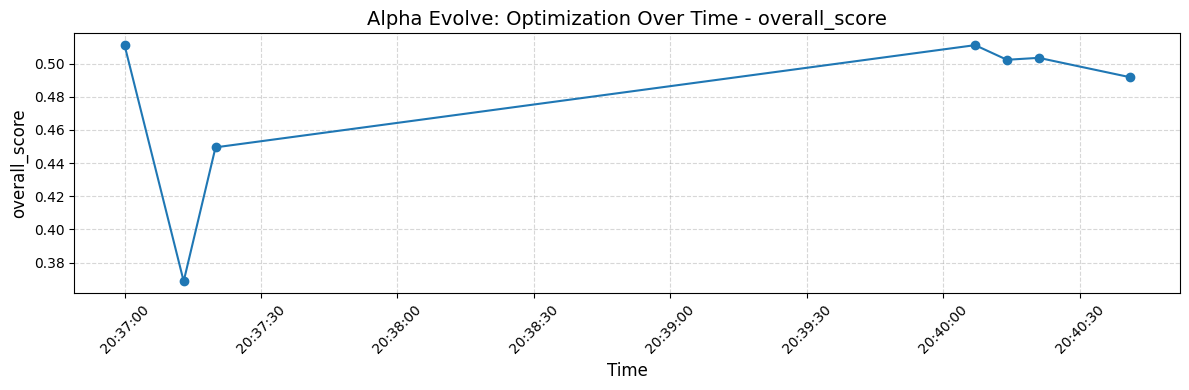

Successfully processed 1 unique metrics.


In [ ]:
plot_metrics()

### Plot the number of successful candidate programs vs failed programs.
---
Inevitably, some of the candidate programs are not syntactically or functionally correct. In that case, we track a failed result. This information is provided to the AlphaEvolve API and we share it here for information purposes.

Dynamically resolved and using metric: overall_score


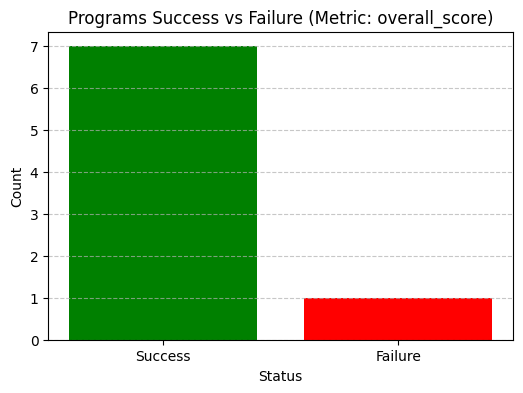

Total Success for overall_score: 7
Total Failure for overall_score: 1


In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import os

plot_success_ves_failure()

### Compare two candidate program instances.
---
For the purposes of illustration, we provide a `diff` of two candidate programs. Typically, there is a substantial difference between candidates.


In [ ]:
%%bash
# Note: Make sure to adjust file names and directory structure
files=($(ls -1 /data/$_USER_EXPERIMENT_NAME/archive/$_PROGRAMS_DIR/$_DEPLOYMENT_NAME-*/main.py | head -n 2))
sdiff "${files[0]}" "${files[1]}"
exit 0

# EVOLVE-BLOCK-START						# EVOLVE-BLOCK-START
"""								"""
Real-Time Adaptive Signal Processing Algorithm for Non-Statio	Real-Time Adaptive Signal Processing Algorithm for Non-Statio

This algorithm implements a sliding window approach to filter	This algorithm implements a sliding window approach to filter
time series data while minimizing noise and preserving signal	time series data while minimizing noise and preserving signal
"""								"""

from collections import deque				      <
							      <
import numpy as np						import numpy as np
from scipy import signal					from scipy import signal


# --- Kalman Filter Implementation for one of the Oracles --- |	def adaptive_filter(x, window_size=20):
class KalmanFilterOracle:				      <
    """							      <
    A simplified 1D Kalman Filter implementation for a consta <
    Used as one of the 'oracles' in the ensemble.	      <
    """							      <
    def __init__(self, initial_estimate=0.0, initial_variance <
                 proces